# Week 6 — Baseline Model: ESI Triage Level Classification
**CariSurg MedTech Pathways 2026 | Josiah-John Green**

---

**Random seed:** `42` | **Dataset:** `triage_cleaned_v1.csv` (Week 5 pipeline output)

**Key setup decisions:**
- `disposition` and `previousdispo` excluded — outcome leakage (hard rule)
- `arrivalmode` encoded as binary ambulance flag (`'ambulance'` is lowercase in this dataset)
- `class_weight='balanced'` on all classifiers — ESI 1 = 0.14% of data (77 of 55,121)
- Temperature in °F not used as a feature in this baseline


## Step 1 — Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, recall_score
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f'Ready. Seed: {RANDOM_SEED}')

Ready. Seed: 42


## Step 2 — Load Data

Load the cleaned CSV from Week 5. Update `FILE_PATH` for your environment.

In [12]:
from pathlib import Path

FILE_PATH = Path("/Users/josiah-john-green/Mobile-Apps/carisurg/datasets/triage_cleaned_v1.csv")
FIGS_PATH = Path("/Users/josiah-john-green/Mobile-Apps/carisurg/figs/week-06")

df = pd.read_csv(FILE_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

# Encode ambulance arrival — note: 'ambulance' is lowercase in this dataset
df['arrival_ambulance'] = (df['arrivalmode'] == 'ambulance').astype(int)
print(f"Ambulance arrivals: {df['arrival_ambulance'].sum():,} ({df['arrival_ambulance'].mean()*100:.1f}%)")
print(f"Leakage columns present: {[c for c in ['disposition','previousdispo'] if c in df.columns]}")
df.head()

Loaded: 55,121 rows x 225 columns
Ambulance arrivals: 18,561 (33.7%)
Leakage columns present: ['disposition', 'previousdispo']


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain,arrival_ambulance
0,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


## Step 3 — Feature Selection (Top-10 from Week 5 memo)

| # | Feature | r vs ESI | Clinical reason |
|---|---------|----------|-----------------|
| 1 | `age` | −0.24 | Strongest signal; reduced physiological reserve |
| 2 | `triage_vital_o2` | +0.18 | SpO₂ — ABCs marker |
| 3 | `cc_chestpain` | −0.16 | ACS/PE rule-out |
| 4 | `cc_shortnessofbreath` | −0.15 | Respiratory distress |
| 5 | `cc_suicidal` | −0.14 | Safety-critical |
| 6 | `cc_alcoholintoxication` | −0.14 | Airway/safety risk |
| 7 | `cc_alteredmentalstatus` | −0.13 | Neuro red flag |
| 8 | `arrival_ambulance` | — | EMS pre-selects sicker patients |
| 9 | `triage_vital_rr` | −0.10 | Early instability |
| 10 | `triage_vital_hr` | −0.10 | Shock marker |

In [13]:
FEATURES = [
    'age', 'triage_vital_o2', 'cc_chestpain', 'cc_shortnessofbreath',
    'cc_suicidal', 'cc_alcoholintoxication', 'cc_alteredmentalstatus',
    'arrival_ambulance', 'triage_vital_rr', 'triage_vital_hr'
]
TARGET = 'esi'

missing = [f for f in FEATURES if f not in df.columns]
print(f'Missing features: {missing if missing else "None"}')

model_df = df[FEATURES + [TARGET]].dropna()
print(f'Rows for modelling: {model_df.shape[0]:,}')
print('\nESI distribution:')
for esi, cnt in model_df[TARGET].value_counts().sort_index().items():
    pct = cnt/len(model_df)*100
    print(f'  ESI {esi}: {cnt:,} ({pct:.2f}%)')

Missing features: None
Rows for modelling: 55,121

ESI distribution:
  ESI 1: 77 (0.14%)
  ESI 2: 17,924 (32.52%)
  ESI 3: 27,010 (49.00%)
  ESI 4: 8,896 (16.14%)
  ESI 5: 1,214 (2.20%)


## Step 4 — Train/Test Split (80/20 stratified)

In [14]:
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'ESI-1 in test set: {(y_test == 1).sum()} patients')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 44,096 | Test: 11,025
ESI-1 in test set: 16 patients


## Step 5 — Primary Metric Justification

**Primary metric: ESI-1 recall. Summary metric: macro recall.**

ESI 1 = cardiac arrest, major trauma, anaphylaxis, shock — immediate resuscitation required.
A false negative sends that patient to wait. In cardiac arrest, survival drops ~10%/minute.

ESI 1 is 0.14% of encounters. A model predicting ESI 1 zero times achieves 99.86% accuracy.
Accuracy is therefore useless. Recall asks the right question: of all ESI-1 patients, how many did the model catch?

Macro recall weights all five classes equally — ESI-1 performance is not buried by majority-class results.
Weighted F1 would let ESI-3 (49% of data) dominate — wrong optimisation target for a triage tool.

**Failure mode we are most worried about:** false negatives on ESI 1.

## Step 6 — Dummy Baseline

In [15]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

print('=== DUMMY (stratified random) ===')
print(f'Accuracy: {accuracy_score(y_test, y_dummy):.3f} | Macro recall: {recall_score(y_test, y_dummy, average="macro", zero_division=0):.3f} | Macro F1: {f1_score(y_test, y_dummy, average="macro", zero_division=0):.3f}')
print(classification_report(y_test, y_dummy, zero_division=0, target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']))

=== DUMMY (stratified random) ===
Accuracy: 0.375 | Macro recall: 0.204 | Macro F1: 0.204
              precision    recall  f1-score   support

       ESI 1       0.00      0.00      0.00        16
       ESI 2       0.33      0.33      0.33      3585
       ESI 3       0.49      0.50      0.49      5402
       ESI 4       0.15      0.15      0.15      1779
       ESI 5       0.05      0.05      0.05       243

    accuracy                           0.38     11025
   macro avg       0.20      0.20      0.20     11025
weighted avg       0.37      0.38      0.37     11025



## Step 7 — Logistic Regression

In [16]:
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_SEED, solver='lbfgs')
lr.fit(X_train_sc, y_train)
y_lr = lr.predict(X_test_sc)

print('=== LOGISTIC REGRESSION ===')
print(f'Accuracy: {accuracy_score(y_test, y_lr):.3f}')
print(f'Macro recall: {recall_score(y_test, y_lr, average="macro", zero_division=0):.3f}')
print(f'Weighted F1: {f1_score(y_test, y_lr, average="weighted", zero_division=0):.3f}')
print(f'Macro F1: {f1_score(y_test, y_lr, average="macro", zero_division=0):.3f}')
print(f'ESI-1 recall: {recall_score(y_test==1, y_lr==1, zero_division=0):.3f}')
print()
print(classification_report(y_test, y_lr, zero_division=0, target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']))

=== LOGISTIC REGRESSION ===
Accuracy: 0.254
Macro recall: 0.417
Weighted F1: 0.327
Macro F1: 0.214
ESI-1 recall: 0.750

              precision    recall  f1-score   support

       ESI 1       0.00      0.75      0.01        16
       ESI 2       0.69      0.31      0.42      3585
       ESI 3       0.58      0.20      0.30      5402
       ESI 4       0.25      0.26      0.26      1779
       ESI 5       0.05      0.57      0.09       243

    accuracy                           0.25     11025
   macro avg       0.31      0.42      0.21     11025
weighted avg       0.55      0.25      0.33     11025



## Step 8 — Logistic Regression Confusion Matrix

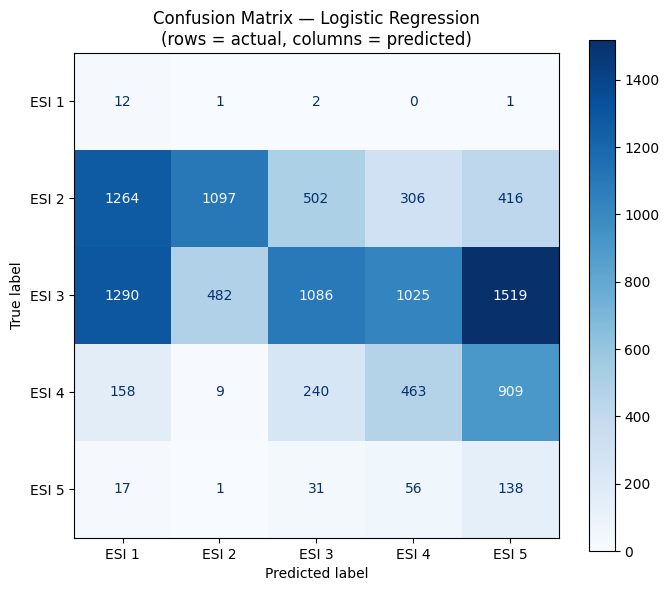

Saved: confusion_matrix_lr.png


In [17]:
fig, ax = plt.subplots(figsize=(7,6))
cm_lr = confusion_matrix(y_test, y_lr, labels=[1,2,3,4,5])
ConfusionMatrixDisplay(cm_lr, display_labels=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression\n(rows = actual, columns = predicted)')
plt.tight_layout()
plt.savefig(FIGS_PATH / "confusion_matrix_lr.png", dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_lr.png')

## Step 9 — LR Coefficient Sanity Check

Positive coefficient = feature pushes toward ESI 1. Expect: chest pain, altered mental status, ambulance arrival to be positive.

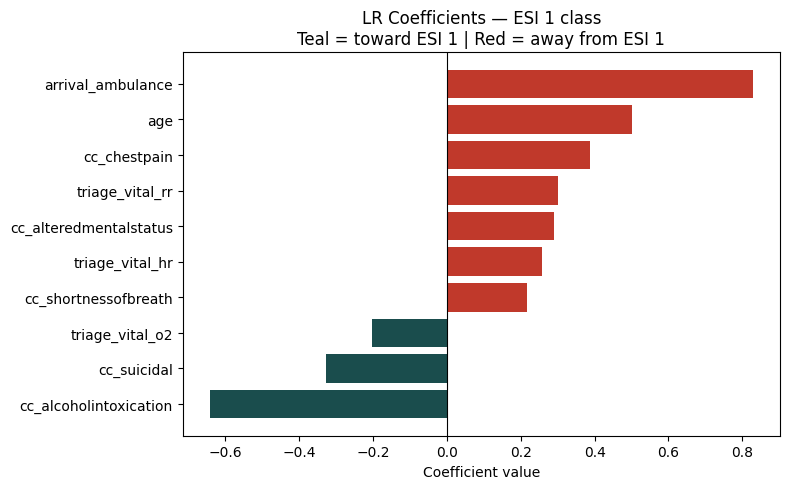

arrival_ambulance         0.8287
age                       0.5018
cc_chestpain              0.3884
triage_vital_rr           0.3014
cc_alteredmentalstatus    0.2892
triage_vital_hr           0.2581
cc_shortnessofbreath      0.2169
triage_vital_o2          -0.2040
cc_suicidal              -0.3289
cc_alcoholintoxication   -0.6423


In [18]:
esi1_idx = list(lr.classes_).index(1)
coefs = pd.Series(lr.coef_[esi1_idx], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8,5))
colors = ['#c0392b' if v > 0 else '#1a4d4d' for v in coefs]
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('LR Coefficients — ESI 1 class\nTeal = toward ESI 1 | Red = away from ESI 1')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.savefig(FIGS_PATH / 'lr_coefficients_esi1.png', dpi=150, bbox_inches='tight')
plt.show()
print(coefs.sort_values(ascending=False).round(4).to_string())

## Step 10 — Decision Tree

In [19]:
# max_depth=5: interpretable + prevents overfitting on 10 features
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_SEED)
dt.fit(X_train, y_train)
y_dt = dt.predict(X_test)

print('=== DECISION TREE (max_depth=5) ===')
print(f'Accuracy: {accuracy_score(y_test, y_dt):.3f}')
print(f'Macro recall: {recall_score(y_test, y_dt, average="macro", zero_division=0):.3f}')
print(f'Weighted F1: {f1_score(y_test, y_dt, average="weighted", zero_division=0):.3f}')
print(f'Macro F1: {f1_score(y_test, y_dt, average="macro", zero_division=0):.3f}')
print(f'ESI-1 recall: {recall_score(y_test==1, y_dt==1, zero_division=0):.3f}')
print()
print(classification_report(y_test, y_dt, zero_division=0, target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']))

=== DECISION TREE (max_depth=5) ===
Accuracy: 0.255
Macro recall: 0.386
Weighted F1: 0.302
Macro F1: 0.170
ESI-1 recall: 0.562

              precision    recall  f1-score   support

       ESI 1       0.01      0.56      0.01        16
       ESI 2       0.50      0.40      0.44      3585
       ESI 3       0.57      0.22      0.32      5402
       ESI 4       0.00      0.00      0.00      1779
       ESI 5       0.04      0.75      0.08       243

    accuracy                           0.25     11025
   macro avg       0.22      0.39      0.17     11025
weighted avg       0.44      0.25      0.30     11025



## Step 11 — Decision Tree Confusion Matrix

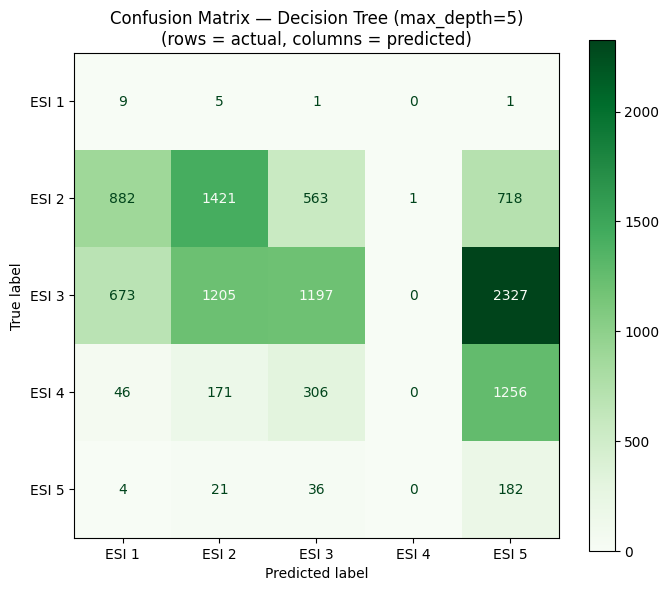

Saved: confusion_matrix_dt.png


In [20]:
fig, ax = plt.subplots(figsize=(7,6))
cm_dt = confusion_matrix(y_test, y_dt, labels=[1,2,3,4,5])
ConfusionMatrixDisplay(cm_dt, display_labels=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']).plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('Confusion Matrix — Decision Tree (max_depth=5)\n(rows = actual, columns = predicted)')
plt.tight_layout()
plt.savefig(FIGS_PATH / 'confusion_matrix_dt.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_dt.png')

## Step 12 — Feature Importances

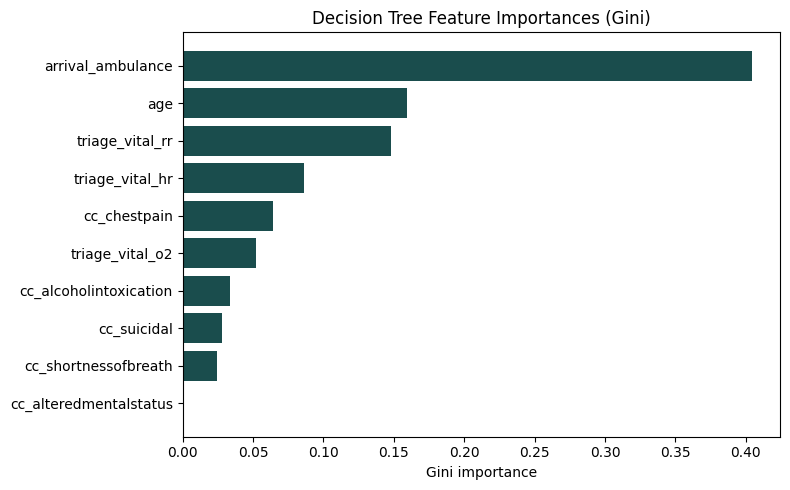

arrival_ambulance         0.4041
age                       0.1592
triage_vital_rr           0.1481
triage_vital_hr           0.0864
cc_chestpain              0.0639
triage_vital_o2           0.0524
cc_alcoholintoxication    0.0339
cc_suicidal               0.0278
cc_shortnessofbreath      0.0242
cc_alteredmentalstatus    0.0000


In [21]:
importance = pd.Series(dt.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(importance.index, importance.values, color='#1a4d4d')
ax.set_title('Decision Tree Feature Importances (Gini)')
ax.set_xlabel('Gini importance')
plt.tight_layout()
plt.savefig(FIGS_PATH / 'dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(importance.sort_values(ascending=False).round(4).to_string())

## Step 13 — Head-to-Head Comparison

In [22]:
results = pd.DataFrame({
    'Model': ['Dummy (stratified)', 'Logistic Regression', 'Decision Tree depth=5'],
    'Accuracy': [accuracy_score(y_test, y_dummy), accuracy_score(y_test, y_lr), accuracy_score(y_test, y_dt)],
    'Macro Recall': [recall_score(y_test, y_dummy, average='macro', zero_division=0), recall_score(y_test, y_lr, average='macro', zero_division=0), recall_score(y_test, y_dt, average='macro', zero_division=0)],
    'ESI-1 Recall': [recall_score(y_test==1, y_dummy==1, zero_division=0), recall_score(y_test==1, y_lr==1, zero_division=0), recall_score(y_test==1, y_dt==1, zero_division=0)],
    'Weighted F1': [f1_score(y_test, y_dummy, average='weighted', zero_division=0), f1_score(y_test, y_lr, average='weighted', zero_division=0), f1_score(y_test, y_dt, average='weighted', zero_division=0)],
    'Macro F1': [f1_score(y_test, y_dummy, average='macro', zero_division=0), f1_score(y_test, y_lr, average='macro', zero_division=0), f1_score(y_test, y_dt, average='macro', zero_division=0)]
}).set_index('Model')
print(results.round(3).to_string())
print(f'\nLR beats dummy on ESI-1 recall by: {results.loc["Logistic Regression","ESI-1 Recall"] - results.loc["Dummy (stratified)","ESI-1 Recall"]:+.3f}')

                       Accuracy  Macro Recall  ESI-1 Recall  Weighted F1  Macro F1
Model                                                                             
Dummy (stratified)        0.375         0.204         0.000        0.375     0.204
Logistic Regression       0.254         0.417         0.750        0.327     0.214
Decision Tree depth=5     0.255         0.386         0.562        0.302     0.170

LR beats dummy on ESI-1 recall by: +0.750


## Step 14 — Macro vs Weighted F1 Explained

**Weighted F1:** ESI-3 (49% of data) dominates. A model ignoring ESI-1 entirely still scores well. Wrong target.

**Macro F1:** equal weight per class. ESI-1 failure is visible and penalised.

**Key results:**
- Accuracy lower for both real models than dummy — expected. `class_weight='balanced'` forces the model to predict minority classes more, reducing majority-class accuracy.
- ESI-1 recall: **LR = 0.75** (12/16), **DT = 0.56** (9/16), **Dummy ≈ 0.14** (random at class frequency)
- **LR is the stronger baseline on the primary metric.**

**Notable: LR ESI-2 recall = 0.31.** ESI-2 (emergent, ≤10 min target) is being missed at high rates — a direct consequence of `balanced` weighting. Worth noting in the failure-mode reflection as a trade-off to tune before any deployment.

## Step 15 — Failure Mode Reflection

**Most worried about:** 4 of 16 ESI-1 patients missed by LR (25% false negative rate). In deployment, those patients wait in the wrong queue.

**Second concern:** ESI-2 recall = 0.31 for LR. Missed ESI-2 patients have strokes, sepsis, ACS — all with 10-minute physician targets. The `balanced` weighting trades ESI-2 precision for ESI-1 and ESI-5 recall. This is a known trade-off, not a surprise, but it needs careful threshold tuning.

**Third concern:** no re-triage capability. A static classifier does not re-evaluate patients who deteriorate post-triage.

**ESI-1 sample caveat:** 16 test-set patients. Each prediction shifts recall by 6.25 points. The 0.75 figure is directionally encouraging but statistically fragile.

**Caribbean mismatch:** this is a US, single-hospital dataset. Nothing here predicts Mercer performance.

## Step 16 — 1-Minute Clinical Explainer Script (for Dr. Reyes)

*~55 seconds at normal pace. No ML jargon.*

---

"Dr. Reyes — we have two ways to measure whether this system is any good. How often it's right overall, and how often it catches every patient who genuinely needs the resuscitation bay. These are not the same thing.

Cardiac arrests are less than one in a thousand patients coming through the door. A system that never flags a single cardiac arrest is right 99.9% of the time. And it fails every patient who needed immediate help.

So we measure the second question. Of every patient who truly needed the resus bay, how many did the model catch? Our logistic regression caught 12 out of 16 of those patients in the test set. Random guessing would catch about 2.

The 4 it missed — that is the failure mode. Those 4 patients would have waited in the wrong place. That number has to come down before this gets near a real patient.

Today's result just tells us the signal exists in the vitals and chief complaints your nurses already collect. Before anything goes near a patient, we test on Caribbean data, at Mercer, with your nurses in the loop."

---